<a href="https://colab.research.google.com/github/plato-chakma/Network-Intrusion-Detection-with-Explainable-AI/blob/main/cyber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install category_encoders xgboost lightgbm catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 14.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ipaddress

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.base import clone

# Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

SEED = 42

In [ ]:
from google.colab import files

file_path = "/content/cybersecurity.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())

Shape: (10000, 13)


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [ ]:
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

print("\nAttack Type Distribution:")
print(df['attack_type'].value_counts())


Data Types:
timestamp              object
src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
bytes_sent              int64
bytes_received          int64
user_agent             object
url                    object
is_internal_traffic      bool
label                   int64
attack_type            object
dtype: object

Missing Values:
timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

Target Distribution:
label
0    9600
1     400
Name: count, dtype: int64
label
0    96.0
1     4.0
Name: proportion, dtype: float64

Attack Type Distribution:
attack_type
benign           

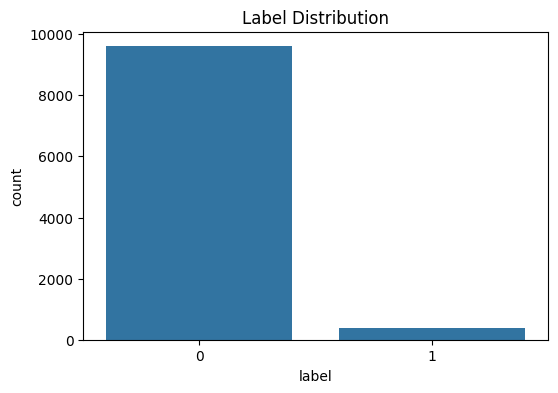

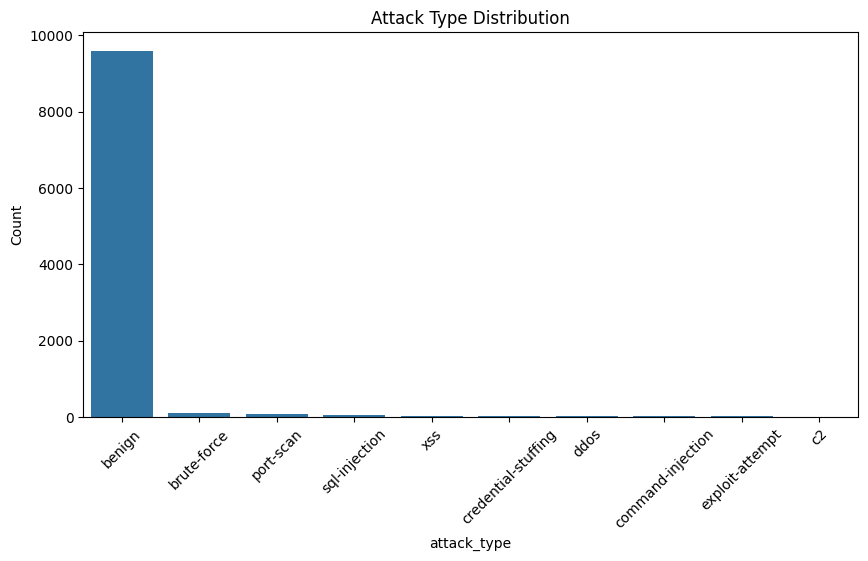

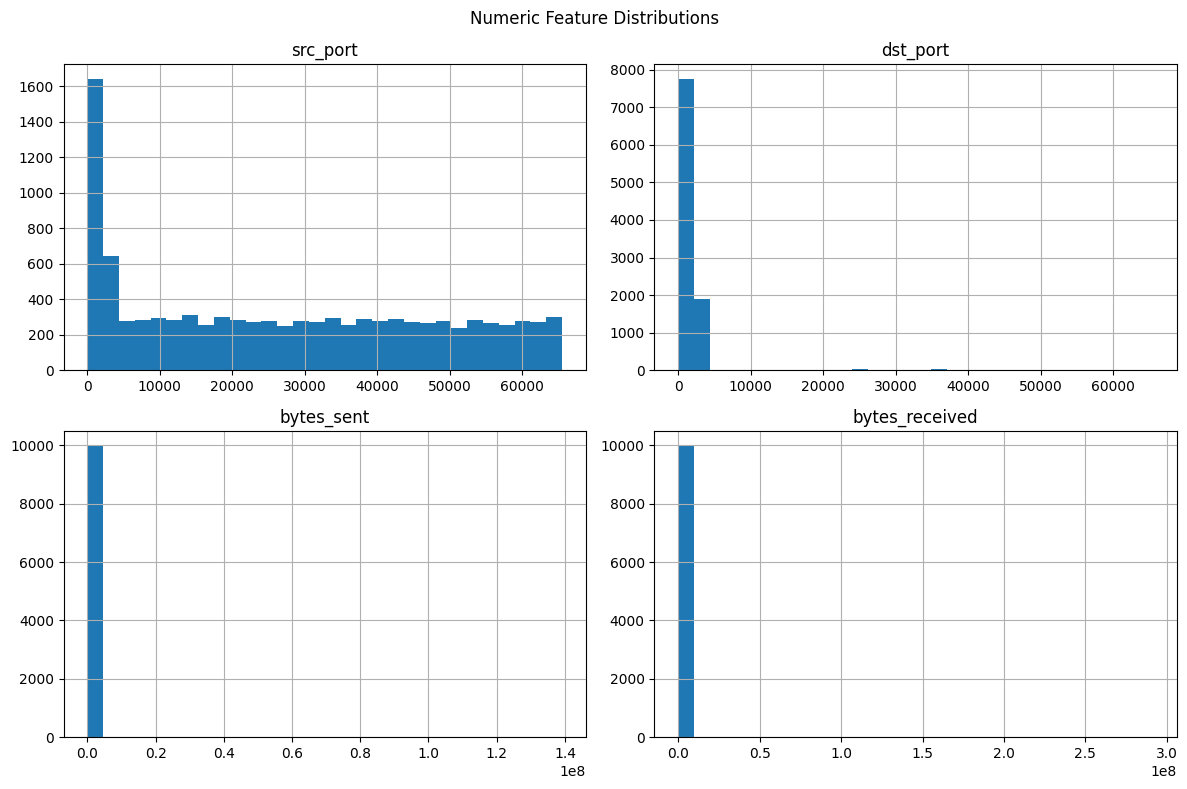

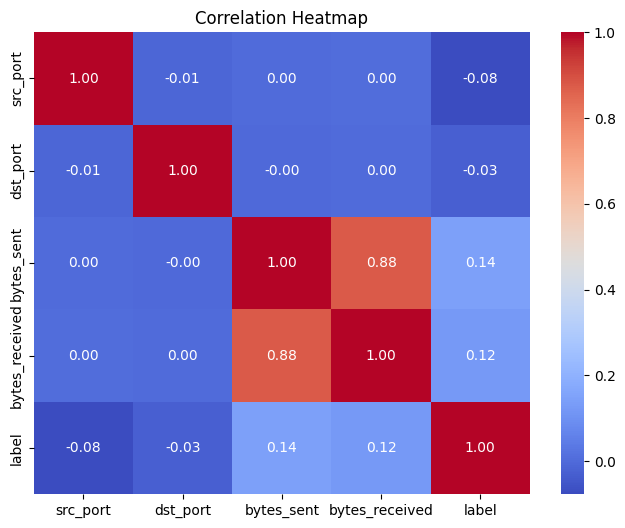

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

plt.figure(figsize=(10,5))
attack_counts = df['attack_type'].value_counts()
sns.barplot(x=attack_counts.index, y=attack_counts.values)
plt.xticks(rotation=45)
plt.title("Attack Type Distribution")
plt.ylabel("Count")
plt.show()

numeric_cols = ['src_port', 'dst_port', 'bytes_sent', 'bytes_received']
df[numeric_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols + ['label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

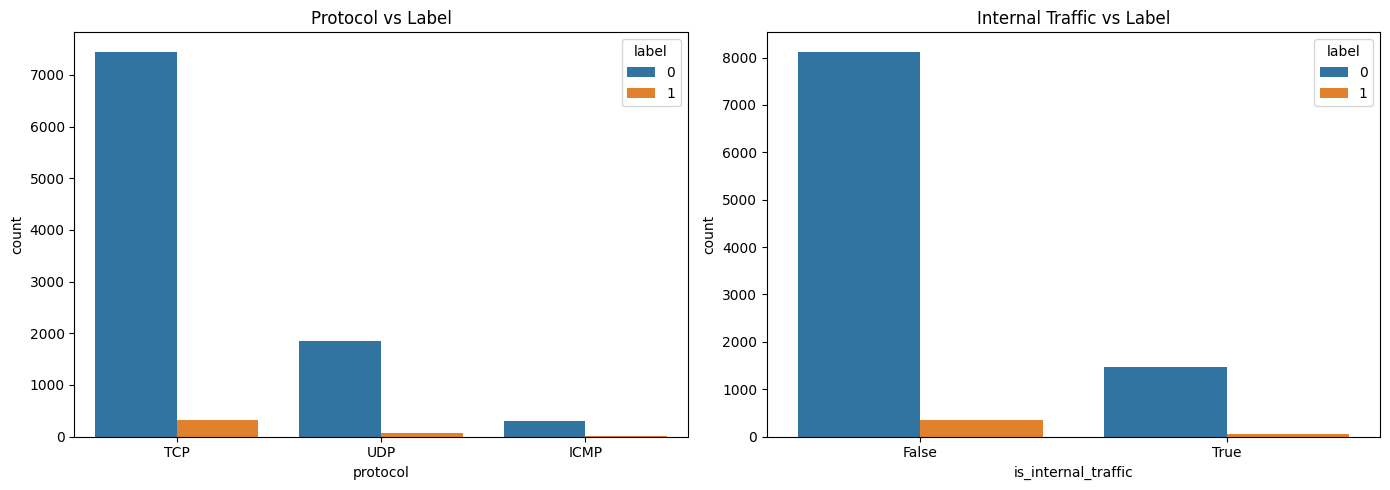

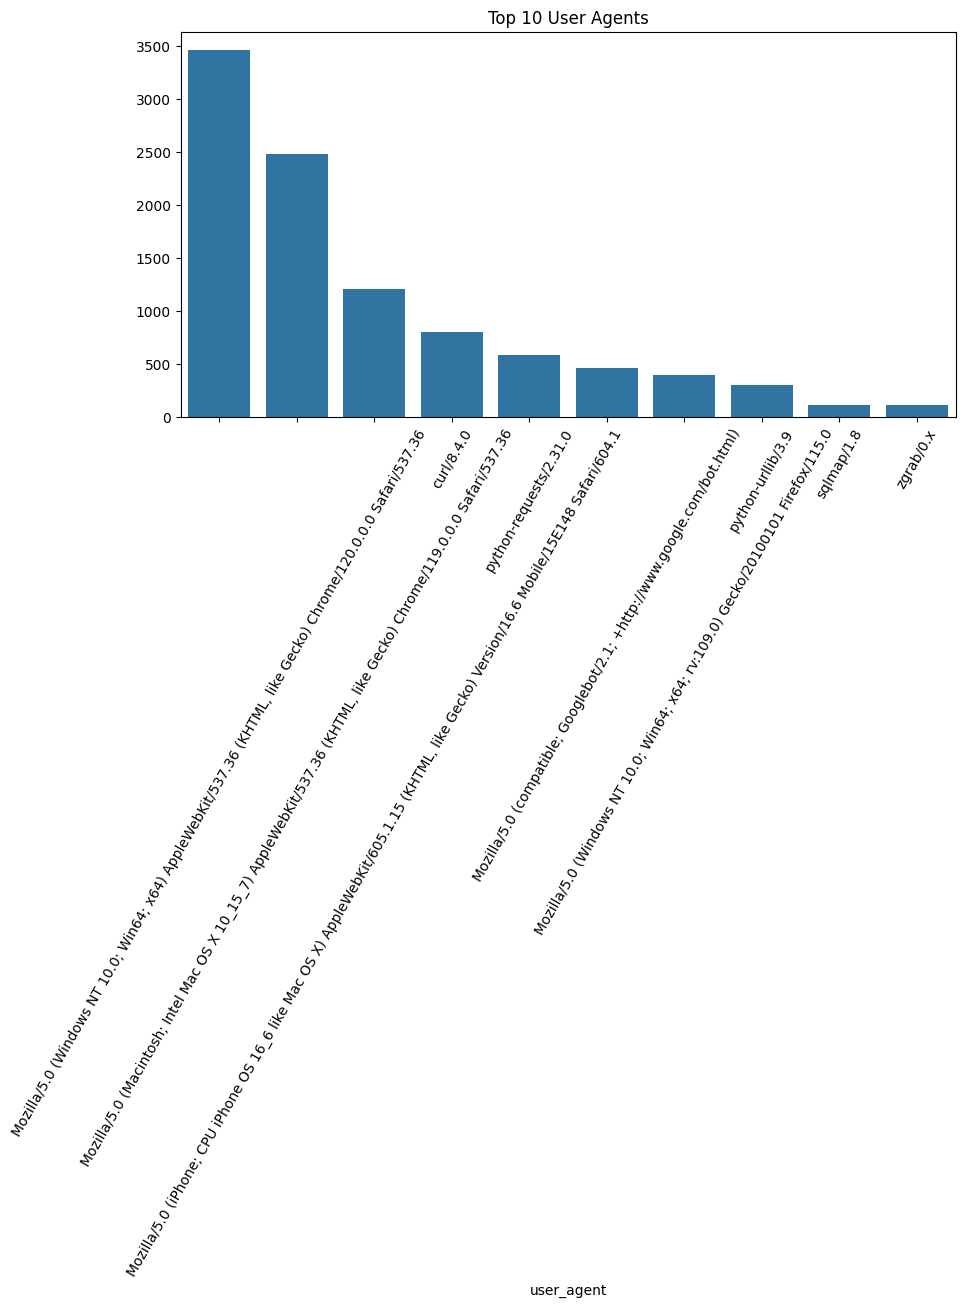

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='protocol', hue='label', data=df, ax=axes[0])
axes[0].set_title("Protocol vs Label")

sns.countplot(x='is_internal_traffic', hue='label', data=df, ax=axes[1])
axes[1].set_title("Internal Traffic vs Label")

plt.tight_layout()
plt.show()

top_agents = df['user_agent'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_agents.index, y=top_agents.values)
plt.xticks(rotation=60)
plt.title("Top 10 User Agents")
plt.show()

In [ ]:
df = df.copy()

# Remove duplicates
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed duplicates: {before - after}")

# Timestamp conversion
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Fill missing URL
df['url'] = df['url'].fillna('no_url')

# Standardize text columns
text_cols = ['src_ip', 'dst_ip', 'protocol', 'user_agent', 'url', 'attack_type']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Boolean to int
df['is_internal_traffic'] = df['is_internal_traffic'].astype(int)

# Drop rows with invalid timestamps if any
invalid_ts = df['timestamp'].isna().sum()
print("Invalid timestamps:", invalid_ts)
df = df.dropna(subset=['timestamp'])

# Ensure no negative bytes
df['bytes_sent'] = df['bytes_sent'].clip(lower=0)
df['bytes_received'] = df['bytes_received'].clip(lower=0)

# Target consistency check
consistency = ((df['label'] == 0) == (df['attack_type'] == 'benign')).all()
print("Label vs attack_type consistency:", consistency)

print("Cleaned shape:", df.shape)
display(df.head())

Removed duplicates: 0
Invalid timestamps: 0
Label vs attack_type consistency: True
Cleaned shape: (10000, 13)


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,tcp,8029,17204,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://webmail.corp/login?id=385071,0,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,tcp,676368,2643374,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://portal.example.org/owa/auth/logon.aspx...,0,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,tcp,316502,38571,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...,no_url,0,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,tcp,70933,21935,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://webmail.corp/phpmyadmin?id=114701,0,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,tcp,12721,9939,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://portal.example.org/config.php?id=345569,0,0,benign


In [ ]:
def is_private_ip(ip):
    try:
        return int(ipaddress.ip_address(ip).is_private)
    except:
        return 0

def get_ip_octets(ip):
    try:
        parts = ip.split('.')
        if len(parts) == 4:
            return [int(p) for p in parts]
        return [0, 0, 0, 0]
    except:
        return [0, 0, 0, 0]

def port_category(port):
    if 0 <= port <= 1023:
        return 'well_known'
    elif 1024 <= port <= 49151:
        return 'registered'
    elif 49152 <= port <= 65535:
        return 'dynamic'
    return 'unknown'

def suspicious_url_features(url):
    url = str(url).lower()
    keywords = ['login', 'admin', 'sql', 'cmd', 'shell', 'token', 'auth', 'wp', 'select', 'union']
    count_keywords = sum(kw in url for kw in keywords)
    return pd.Series({
        'url_length': len(url),
        'url_num_digits': sum(c.isdigit() for c in url),
        'url_num_special': sum(not c.isalnum() for c in url),
        'url_num_slashes': url.count('/'),
        'url_num_dots': url.count('.'),
        'url_has_http': int('http' in url),
        'url_has_query': int('?' in url),
        'url_suspicious_kw_count': count_keywords
    })

def user_agent_features(ua):
    ua = str(ua).lower()
    return pd.Series({
        'ua_length': len(ua),
        'ua_is_browser': int(any(x in ua for x in ['mozilla', 'chrome', 'safari', 'firefox', 'edge'])),
        'ua_is_script': int(any(x in ua for x in ['python', 'curl', 'wget', 'bot', 'scanner'])),
        'ua_is_empty_like': int(ua in ['-', 'unknown', 'nan', 'none', '']),
    })

In [ ]:
# Time-based features
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['day'] = df['timestamp'].dt.day
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Traffic features
df['total_bytes'] = df['bytes_sent'] + df['bytes_received']
df['byte_diff'] = df['bytes_sent'] - df['bytes_received']
df['byte_ratio'] = df['bytes_sent'] / (df['bytes_received'] + 1)

# Port categories
df['src_port_category'] = df['src_port'].apply(port_category)
df['dst_port_category'] = df['dst_port'].apply(port_category)

# Common port flags
common_ports = [20, 21, 22, 23, 25, 53, 80, 110, 123, 143, 443, 3306, 3389, 8080]
df['src_is_common_port'] = df['src_port'].isin(common_ports).astype(int)
df['dst_is_common_port'] = df['dst_port'].isin(common_ports).astype(int)

# IP features
src_octets = df['src_ip'].apply(get_ip_octets).tolist()
dst_octets = df['dst_ip'].apply(get_ip_octets).tolist()

src_octets_df = pd.DataFrame(src_octets, columns=['src_ip_o1', 'src_ip_o2', 'src_ip_o3', 'src_ip_o4'], index=df.index)
dst_octets_df = pd.DataFrame(dst_octets, columns=['dst_ip_o1', 'dst_ip_o2', 'dst_ip_o3', 'dst_ip_o4'], index=df.index)

df = pd.concat([df, src_octets_df, dst_octets_df], axis=1)

df['src_is_private'] = df['src_ip'].apply(is_private_ip)
df['dst_is_private'] = df['dst_ip'].apply(is_private_ip)
df['same_subnet_24'] = ((df['src_ip_o1'] == df['dst_ip_o1']) &
                        (df['src_ip_o2'] == df['dst_ip_o2']) &
                        (df['src_ip_o3'] == df['dst_ip_o3'])).astype(int)

# URL features
url_feats = df['url'].apply(suspicious_url_features)
df = pd.concat([df, url_feats], axis=1)

# User agent features
ua_feats = df['user_agent'].apply(user_agent_features)
df = pd.concat([df, ua_feats], axis=1)

print("Feature engineered shape:", df.shape)
display(df.head())

Feature engineered shape: (10000, 47)


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,...,url_num_special,url_num_slashes,url_num_dots,url_has_http,url_has_query,url_suspicious_kw_count,ua_length,ua_is_browser,ua_is_script,ua_is_empty_like
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,tcp,8029,17204,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://webmail.corp/login?id=385071,...,7,3,1,1,1,1,111,1,0,0
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,tcp,676368,2643374,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://portal.example.org/owa/auth/logon.aspx...,...,11,5,3,1,1,1,111,1,0,0
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,tcp,316502,38571,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...,no_url,...,1,0,0,0,0,0,80,1,0,0
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,tcp,70933,21935,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://webmail.corp/phpmyadmin?id=114701,...,7,3,1,1,1,1,111,1,0,0
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,tcp,12721,9939,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,https://portal.example.org/config.php?id=345569,...,9,3,3,1,1,0,111,1,0,0


In [ ]:
print("===== PRE-MODELING CHECKPOINTS =====")

print("\n1. Shape:", df.shape)

print("\n2. Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n3. Duplicate rows:", df.duplicated().sum())

print("\n4. Target distribution:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

print("\n5. Class imbalance ratio (minority %):")
minority_pct = df['label'].mean() * 100
print(f"{minority_pct:.2f}% malicious")

print("\n6. Unique values per categorical column:")
for col in ['protocol', 'user_agent', 'url', 'src_port_category', 'dst_port_category', 'attack_type']:
    print(f"{col}: {df[col].nunique()}")

print("\n7. Leakage check:")
print("attack_type should NOT be used as feature because it directly reveals target.")
print("timestamp raw column will be dropped after extracting features.")

===== PRE-MODELING CHECKPOINTS =====

1. Shape: (10000, 47)

2. Missing values:
Series([], dtype: int64)

3. Duplicate rows: 0

4. Target distribution:
label
0    9600
1     400
Name: count, dtype: int64
label
0    0.96
1    0.04
Name: proportion, dtype: float64

5. Class imbalance ratio (minority %):
4.00% malicious

6. Unique values per categorical column:
protocol: 3
user_agent: 13
url: 6769
src_port_category: 3
dst_port_category: 3
attack_type: 10

7. Leakage check:
attack_type should NOT be used as feature because it directly reveals target.
timestamp raw column will be dropped after extracting features.


In [ ]:
target = 'label'

drop_cols = ['label', 'attack_type', 'timestamp']  # attack_type is leakage
X = df.drop(columns=drop_cols)
y = df[target]

print("Feature columns:", X.columns.tolist())
print("Number of features:", X.shape[1])

Feature columns: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'hour', 'dayofweek', 'day', 'is_weekend', 'total_bytes', 'byte_diff', 'byte_ratio', 'src_port_category', 'dst_port_category', 'src_is_common_port', 'dst_is_common_port', 'src_ip_o1', 'src_ip_o2', 'src_ip_o3', 'src_ip_o4', 'dst_ip_o1', 'dst_ip_o2', 'dst_ip_o3', 'dst_ip_o4', 'src_is_private', 'dst_is_private', 'same_subnet_24', 'url_length', 'url_num_digits', 'url_num_special', 'url_num_slashes', 'url_num_dots', 'url_has_http', 'url_has_query', 'url_suspicious_kw_count', 'ua_length', 'ua_is_browser', 'ua_is_script', 'ua_is_empty_like']
Number of features: 44


In [ ]:
 X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (8000, 44)
Test shape: (2000, 44)
Train target distribution:
 label
0    0.96
1    0.04
Name: proportion, dtype: float64
Test target distribution:
 label
0    0.96
1    0.04
Name: proportion, dtype: float64


In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Numeric features: ['src_port', 'dst_port', 'bytes_sent', 'bytes_received', 'is_internal_traffic', 'hour', 'dayofweek', 'day', 'is_weekend', 'total_bytes', 'byte_diff', 'byte_ratio', 'src_is_common_port', 'dst_is_common_port', 'src_ip_o1', 'src_ip_o2', 'src_ip_o3', 'src_ip_o4', 'dst_ip_o1', 'dst_ip_o2', 'dst_ip_o3', 'dst_ip_o4', 'src_is_private', 'dst_is_private', 'same_subnet_24', 'url_length', 'url_num_digits', 'url_num_special', 'url_num_slashes', 'url_num_dots', 'url_has_http', 'url_has_query', 'url_suspicious_kw_count', 'ua_length', 'ua_is_browser', 'ua_is_script', 'ua_is_empty_like']
Categorical features: ['src_ip', 'dst_ip', 'protocol', 'user_agent', 'url', 'src_port_category', 'dst_port_category']


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED),
    "RidgeClassifier": RidgeClassifier(class_weight='balanced', random_state=SEED),
    "SGDClassifier": SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=2000, random_state=SEED),
    "PassiveAggressive": PassiveAggressiveClassifier(class_weight='balanced', max_iter=2000, random_state=SEED),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(random_state=SEED),
    "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
    "GaussianNB": GaussianNB(),
    "SVC": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, eval_metric='logloss', random_state=SEED, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, random_state=SEED, class_weight='balanced'
    )
}

In [ ]:
from sklearn.preprocessing import FunctionTransformer

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []

for name, model in models.items():
    print(f"Running CV for {name}...")
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)), # Convert sparse output to dense
        ('model', model)
    ])

    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )

    row = {'Model': name}
    for metric in scoring.keys():
        row[f'CV_{metric}'] = scores[f'test_{metric}'].mean()
    cv_results.append(row)

cv_df = pd.DataFrame(cv_results).sort_values(by='CV_f1', ascending=False).reset_index(drop=True)
display(cv_df)

Running CV for LogisticRegression...
Running CV for RidgeClassifier...
Running CV for SGDClassifier...
Running CV for PassiveAggressive...
Running CV for KNeighbors...
Running CV for DecisionTree...
Running CV for RandomForest...
Running CV for ExtraTrees...
Running CV for AdaBoost...
Running CV for GradientBoosting...
Running CV for HistGradientBoosting...
Running CV for GaussianNB...
Running CV for SVC...
Running CV for MLPClassifier...
Running CV for XGBoost...
Running CV for LightGBM...


,Model,CV_accuracy,CV_precision,CV_recall,CV_f1,CV_roc_auc,CV_average_precision
0,LightGBM,0.972750,0.725870,0.521875,0.604735,0.919775,0.672841
1,DecisionTree,0.957375,0.485111,0.575000,0.521030,0.774154,0.297616
2,HistGradientBoosting,0.971000,0.842675,0.340625,0.480756,0.928353,0.684893
3,XGBoost,0.968500,0.836987,0.262500,0.396637,0.906276,0.630300
4,GradientBoosting,0.968500,0.941037,0.228125,0.363621,0.840137,0.501333
5,PassiveAggressive,0.964000,0.631917,0.237500,0.341910,0.807304,0.350113
6,RidgeClassifier,0.967875,0.988889,0.200000,0.329196,0.865570,0.395008
7,LogisticRegression,0.945500,0.321626,0.331250,0.325527,0.861464,0.371587
8,MLPClassifier,0.945375,0.311817,0.300000,0.305421,0.853526,0.367622
9,SGDClassifier,0.932625,0.271222,0.350000,0.298154,0.809399,0.295783


In [ ]:
test_results = []
fitted_models = {}

for name, model in models.items():
    print(f"Training {name} on full train set...")
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)), # Convert sparse output to dense
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps['model'], "predict_proba"):
        # Some models (like RidgeClassifier) have decision_function but not predict_proba
        # Some models (like GaussianNB) don't have predict_proba or decision_function
        try:
            y_prob = pipe.predict_proba(X_test)[:, 1]
        except AttributeError:
            if hasattr(pipe.named_steps['model'], "decision_function"):
                y_prob = pipe.decision_function(X_test)
            else:
                y_prob = y_pred # Fallback if neither is available
    elif hasattr(pipe.named_steps['model'], "decision_function"):
        y_prob = pipe.decision_function(X_test)
    else:
        y_prob = y_pred

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan, # Handle single class case
        'PR_AUC': average_precision_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan
    }
    test_results.append(row)

test_df = pd.DataFrame(test_results).sort_values(by='F1', ascending=False).reset_index(drop=True)
display(test_df)

Training LogisticRegression on full train set...
Training RidgeClassifier on full train set...
Training SGDClassifier on full train set...
Training PassiveAggressive on full train set...
Training KNeighbors on full train set...
Training DecisionTree on full train set...
Training RandomForest on full train set...
Training ExtraTrees on full train set...
Training AdaBoost on full train set...
Training GradientBoosting on full train set...
Training HistGradientBoosting on full train set...
Training GaussianNB on full train set...
Training SVC on full train set...
Training MLPClassifier on full train set...
Training XGBoost on full train set...
Training LightGBM on full train set...
[LightGBM] [Info] Number of positive: 320, number of negative: 7680
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] 

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.9715,0.709091,0.4875,0.577778,0.929329,0.643431
1,DecisionTree,0.9640,0.548780,0.5625,0.555556,0.771615,0.326189
2,HistGradientBoosting,0.9730,0.882353,0.3750,0.526316,0.923105,0.677164
3,SGDClassifier,0.9615,0.534884,0.2875,0.373984,0.847109,0.412046
4,XGBoost,0.9670,0.791667,0.2375,0.365385,0.936536,0.628283
5,LogisticRegression,0.9430,0.326531,0.4000,0.359551,0.865117,0.416786
6,GradientBoosting,0.9685,1.000000,0.2125,0.350515,0.851022,0.496144
7,MLPClassifier,0.9465,0.337349,0.3500,0.343558,0.864460,0.399635
8,PassiveAggressive,0.9635,0.612903,0.2375,0.342342,0.834909,0.380959
9,SVC,0.9240,0.239130,0.4125,0.302752,0.843932,0.239628


In [ ]:
# CatBoost can take raw categorical columns directly
cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=SEED,
    verbose=0
)

cat_model.fit(
    X_train_cb, y_train,
    cat_features=cat_features
)

y_pred_cb = cat_model.predict(X_test_cb)
y_prob_cb = cat_model.predict_proba(X_test_cb)[:, 1]

cat_result = pd.DataFrame([{
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(y_test, y_pred_cb),
    'Precision': precision_score(y_test, y_pred_cb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_cb, zero_division=0),
    'F1': f1_score(y_test, y_pred_cb, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test, y_prob_cb),
    'PR_AUC': average_precision_score(y_test, y_prob_cb)
}])

display(cat_result)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.9705,0.83871,0.325,0.468468,0.936302,0.719397


In [ ]:
all_results = pd.concat([test_df, cat_result], ignore_index=True)
all_results = all_results.sort_values(by='F1', ascending=False).reset_index(drop=True)
display(all_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.9715,0.709091,0.4875,0.577778,0.929329,0.643431
1,DecisionTree,0.9640,0.548780,0.5625,0.555556,0.771615,0.326189
2,HistGradientBoosting,0.9730,0.882353,0.3750,0.526316,0.923105,0.677164
3,CatBoost,0.9705,0.838710,0.3250,0.468468,0.936302,0.719397
4,SGDClassifier,0.9615,0.534884,0.2875,0.373984,0.847109,0.412046
5,XGBoost,0.9670,0.791667,0.2375,0.365385,0.936536,0.628283
6,LogisticRegression,0.9430,0.326531,0.4000,0.359551,0.865117,0.416786
7,GradientBoosting,0.9685,1.000000,0.2125,0.350515,0.851022,0.496144
8,MLPClassifier,0.9465,0.337349,0.3500,0.343558,0.864460,0.399635
9,PassiveAggressive,0.9635,0.612903,0.2375,0.342342,0.834909,0.380959


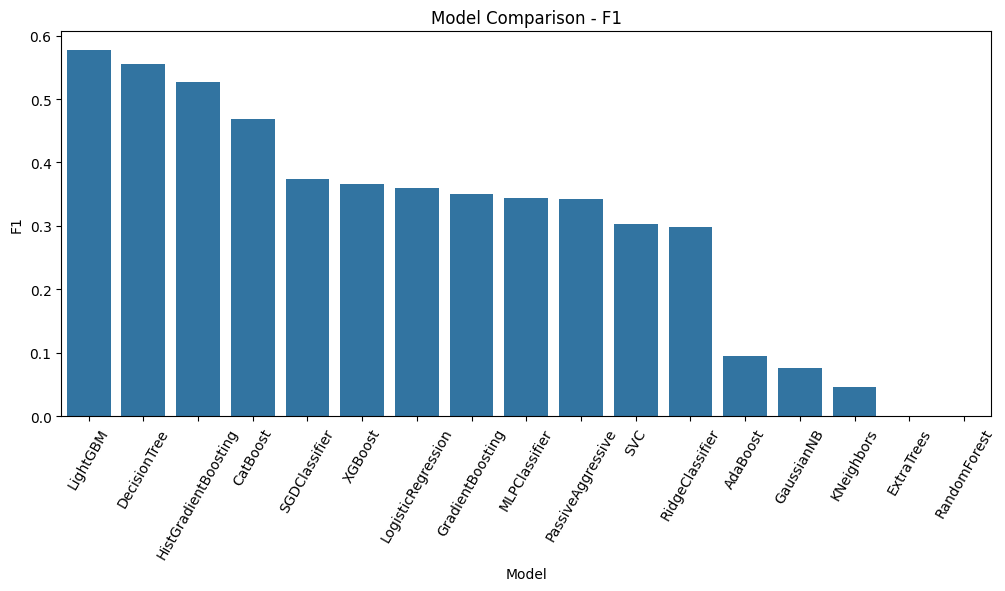

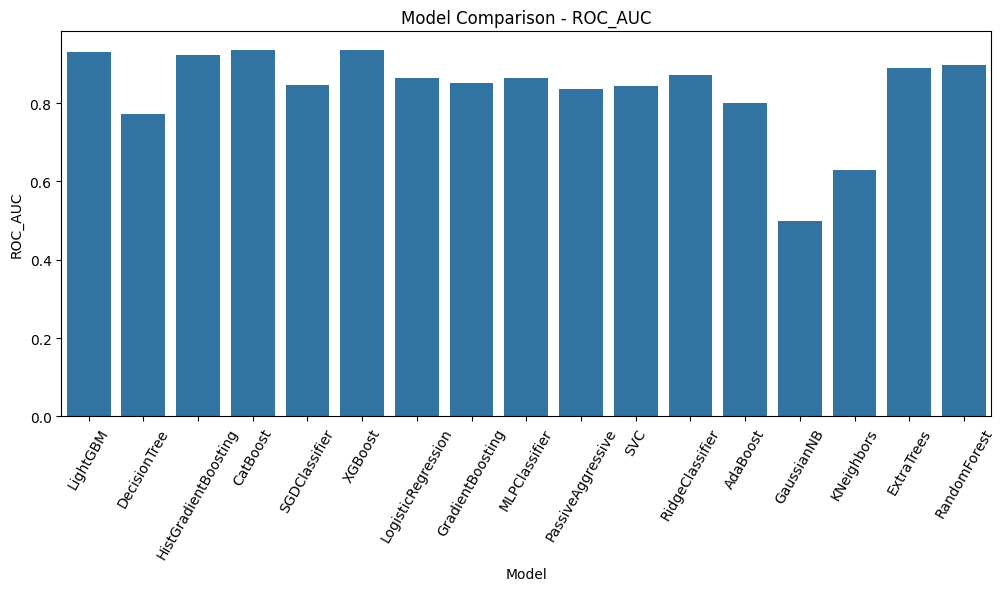

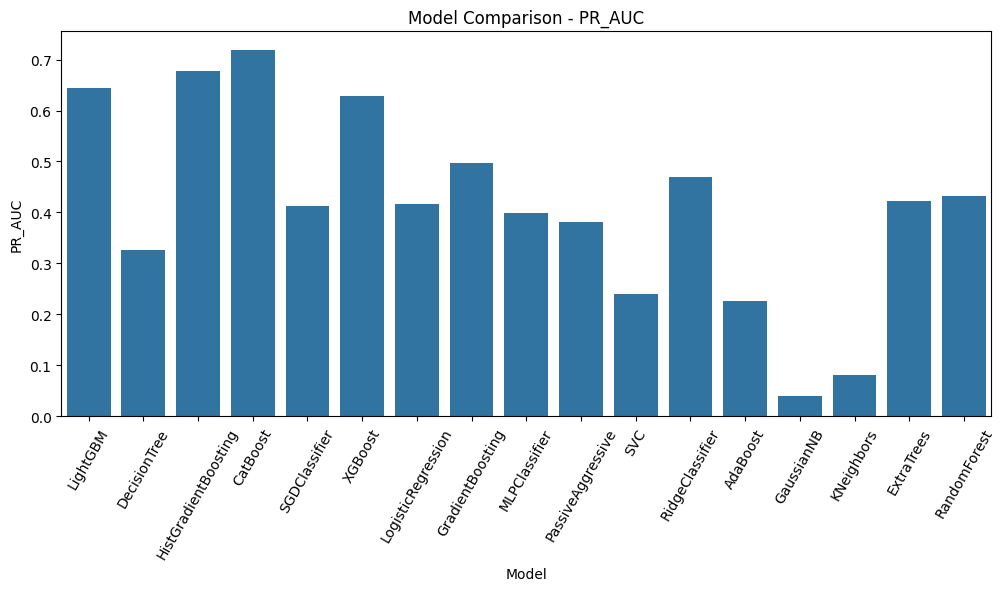

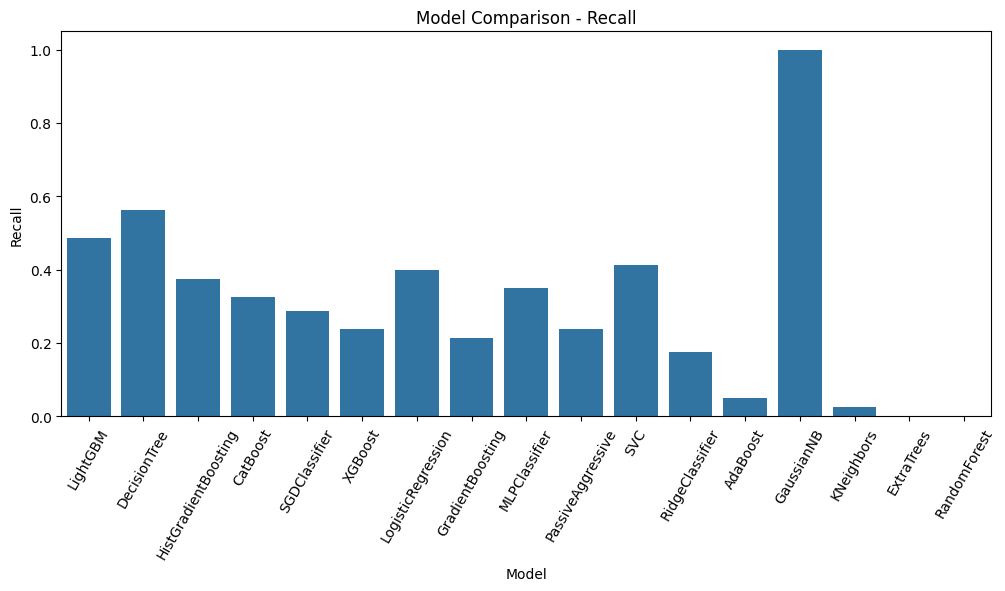

In [ ]:
metrics_to_plot = ['F1', 'ROC_AUC', 'PR_AUC', 'Recall']

for metric in metrics_to_plot:
    plt.figure(figsize=(12,5))
    sns.barplot(data=all_results, x='Model', y=metric)
    plt.xticks(rotation=60)
    plt.title(f'Model Comparison - {metric}')
    plt.show()

In [ ]:
best_model_name = all_results.iloc[0]['Model']
print("Best model based on F1:", best_model_name)

if best_model_name == 'CatBoost':
    best_model = cat_model
else:
    best_model = fitted_models[best_model_name]

Best model based on F1: LightGBM


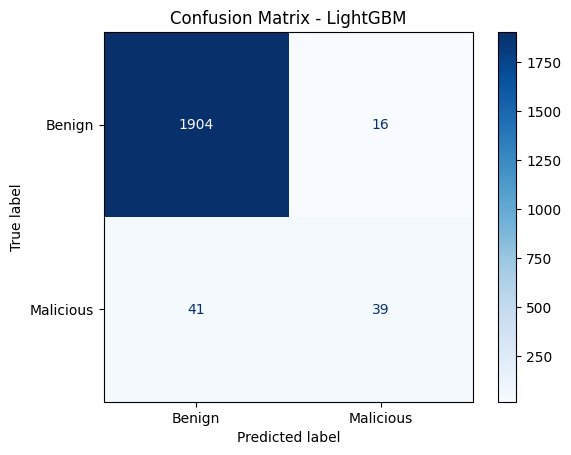

              precision    recall  f1-score   support

           0     0.9789    0.9917    0.9853      1920
           1     0.7091    0.4875    0.5778        80

    accuracy                         0.9715      2000
   macro avg     0.8440    0.7396    0.7815      2000
weighted avg     0.9681    0.9715    0.9690      2000



In [ ]:
if best_model_name == 'CatBoost':
    y_pred_best = cat_model.predict(X_test_cb)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malicious'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print(classification_report(y_test, y_pred_best, digits=4))

In [ ]:
if best_model_name == 'CatBoost':
    importances = cat_model.get_feature_importance()
    feat_imp = pd.DataFrame({
        'feature': X_train_cb.columns,
        'importance': importances
    }).sort_values(by='importance', ascending=False).head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp, x='importance', y='feature')
    plt.title('Top 20 CatBoost Feature Importances')
    plt.show()

    display(feat_imp)

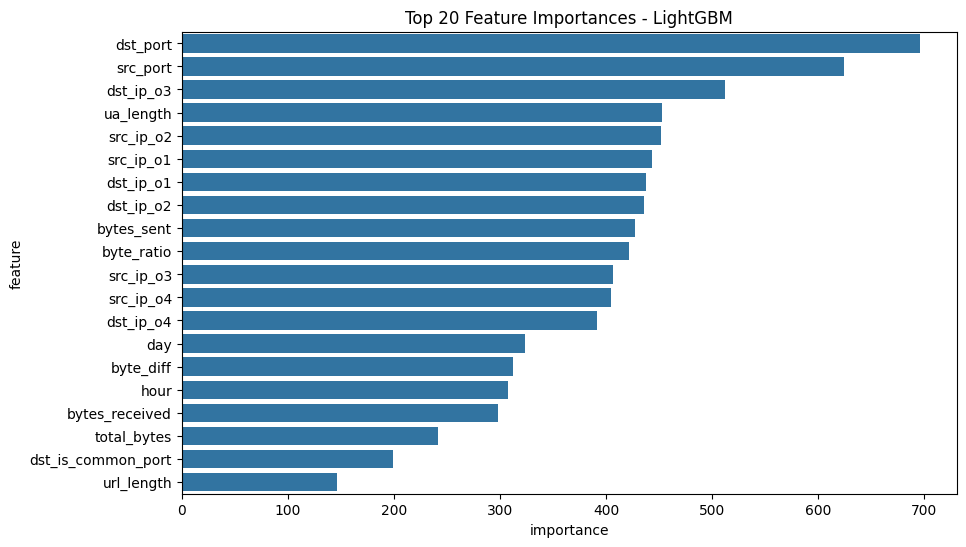

,feature,importance
1,dst_port,696
0,src_port,624
20,dst_ip_o3,512
33,ua_length,453
15,src_ip_o2,452
14,src_ip_o1,443
18,dst_ip_o1,438
19,dst_ip_o2,436
2,bytes_sent,427
11,byte_ratio,422


In [ ]:
tree_models = ['RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM', 'DecisionTree', 'AdaBoost', 'GradientBoosting']

if best_model_name in tree_models:
    pipe = best_model
    model = pipe.named_steps['model']
    ohe = pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']

    encoded_cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(encoded_cat_names)

    importances = model.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp, x='importance', y='feature')
    plt.title(f'Top 20 Feature Importances - {best_model_name}')
    plt.show()

    display(feat_imp)

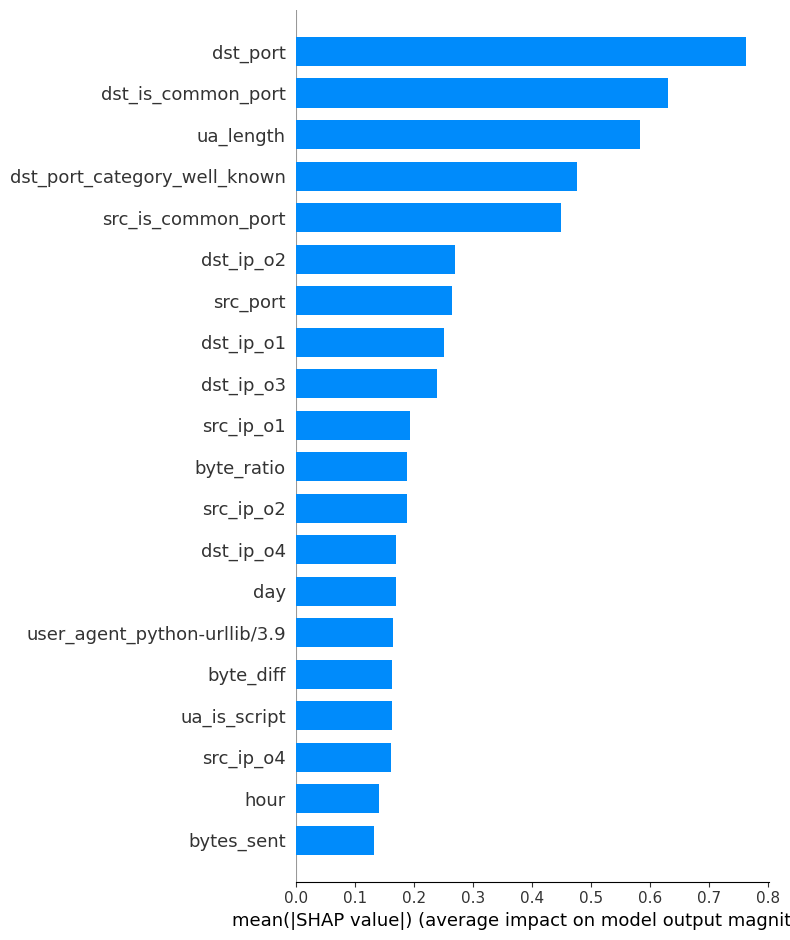

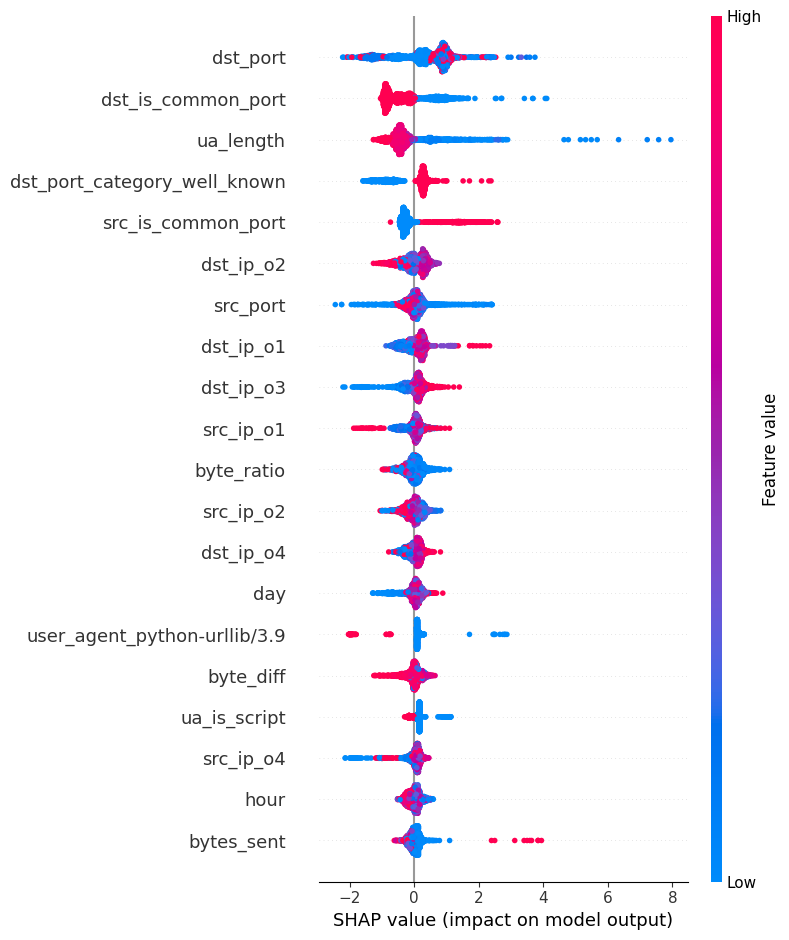

In [ ]:
import shap

if best_model_name == 'CatBoost':
    explainer = shap.TreeExplainer(cat_model)
    shap_values = explainer.shap_values(X_test_cb)

    shap.summary_plot(shap_values, X_test_cb, plot_type='bar')
    shap.summary_plot(shap_values, X_test_cb)

elif best_model_name in ['RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM', 'DecisionTree', 'AdaBoost', 'GradientBoosting']:
    pipe = best_model
    model = pipe.named_steps['model']

    # Extract the preprocessing part of the pipeline
    # The 'transform' method of a Pipeline will fail if the *last* step does not have a 'transform' method.
    # Our 'model' step (e.g., LGBMClassifier) does not have a 'transform' method.
    # So, we create a sub-pipeline including only the preprocessing steps.
    preprocessing_pipeline = Pipeline(pipe.steps[:-1]) # All steps except the last one ('model')
    X_test_transformed = preprocessing_pipeline.transform(X_test)


    ohe = pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    encoded_cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(encoded_cat_names)

    explainer = shap.TreeExplainer(model)
    # shap_values can be a list of arrays for multi-class/binary classification
    # For binary classification, it typically returns [shap_values_for_class_0, shap_values_for_class_1]
    # We want to plot for the positive class (class 1)
    shap_values_list = explainer.shap_values(X_test_transformed)

    # Check if shap_values_list is a list and has at least two elements (for binary classification)
    if isinstance(shap_values_list, list) and len(shap_values_list) > 1:
        shap_values_to_plot = shap_values_list[1] # Take SHAP values for the positive class (class 1)
    else:
        shap_values_to_plot = shap_values_list # Otherwise, use as is (might be a single array for regression/binary)

    shap.summary_plot(shap_values_to_plot, features=X_test_transformed, feature_names=feature_names, plot_type='bar')
    shap.summary_plot(shap_values_to_plot, features=X_test_transformed, feature_names=feature_names) # For beeswarm plot
else:
    print("SHAP full tree explanation is best supported for CatBoost / tree-based models.")